# 1. SETUP AND IMPORTS

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Text processing
import re
import warnings
warnings.filterwarnings('ignore')

# Model persistence
import joblib

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. LOAD

In [5]:
try:
    # Load dataset
    df = pd.read_csv('https://github.com/RanoshisDas/AI-based-cyberbullying-detection-system/raw/refs/heads/main/output.csv')
    print(f"✓ Dataset loaded successfully!")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    
except FileNotFoundError:
    print("✗ Error: Dataset file not found!")
    print("  Please check the file path.")
except Exception as e:
    print(f"✗ Error loading dataset: {str(e)}")

✓ Dataset loaded successfully!
  Shape: (33910, 4)
  Columns: ['Unnamed: 0', 'text', 'label', 'final_label']


# 3. EXPLORATORY DATA ANALYSIS (EDA)


EXPLORATORY DATA ANALYSIS

1. Dataset Information:
   Total samples: 33910
   Features: 4

   Columns: ['Unnamed: 0', 'text', 'label', 'final_label']

2. Missing Values:
text    1
dtype: int64

3. Duplicate rows: 0
   ✓ Removed 'Unnamed: 0' column

4. Label Distribution:

Original labels:
label
eng_religion     1288
eng_race         1280
eng_sex          1280
eng_neutral      1152
tur_bully        1071
por_bully        1048
rus_bully        1039
spa_bully        1038
ita_bully        1037
ara_bully        1033
ind_bully        1025
fre_nonbully     1004
ger_nonbully     1001
ben_neutral       999
ger_bully         999
ben_sexual        998
ben_threat        997
fre_bully         996
ben_troll         996
hin_fake          978
ind_nonbully      970
ara_nonbully      967
spa_nonbully      962
ita_nonbully      960
rus_nonbully      960
por_nonbully      952
tur_nonbully      929
ben_political     899
hin_neutral       859
hin_hate          788
hin_offense       735
kor_bully         648

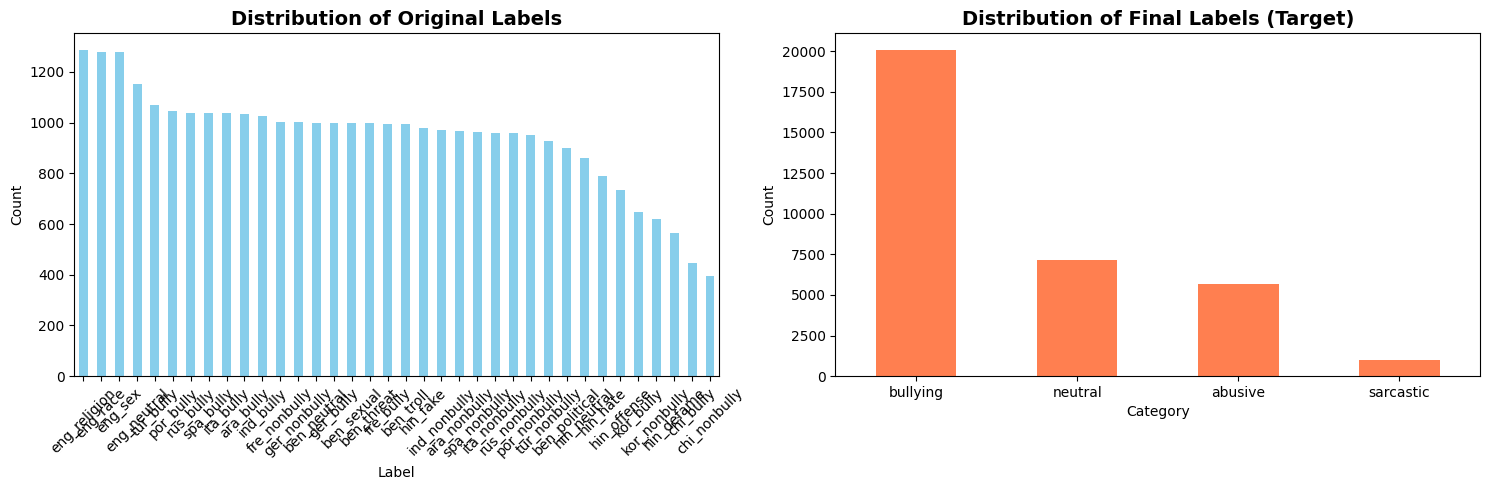


5. Text Length Statistics:
               count        mean         std   min    25%    50%     75%  \
final_label                                                                
abusive       5652.0  158.882696  113.914250   3.0  75.00  135.0  244.00   
bullying     20097.0  104.699060  174.839614   1.0  40.00   80.0  125.00   
neutral       7182.0  102.155806  102.275866   2.0  39.25   72.0  131.00   
sarcastic      978.0  183.691207  165.665831  22.0  87.00  143.0  237.75   

                 max  
final_label           
abusive       1767.0  
bullying     18157.0  
neutral       1000.0  
sarcastic     2256.0  


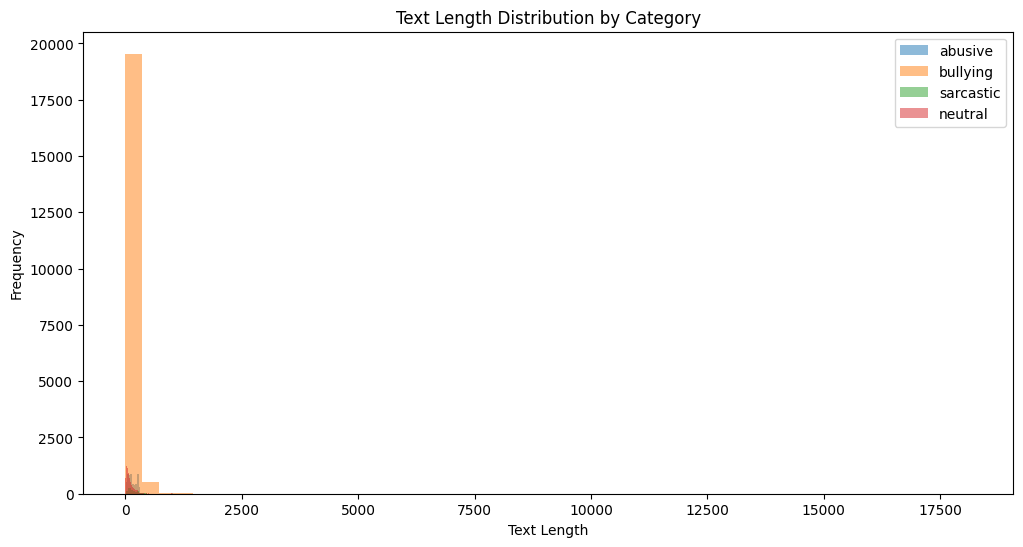


6. Sample Texts from Each Category:

ABUSIVE:
  #Quran
 #Qurantime 
#QuranHour #quran_thedivinebook

 And if you ever #obey a #human like yourselves...

BULLYING:
  t'as pas honte d'opprimer les gens comme ça espèce de coco anarcho-socialo-islamo-gauchiste ? (je cr...

SARCASTIC:
  सबरीमाला में महिलाओं के प्रवेश पर सुप्रीम कोर्ट के आदेश की तुलना केरल में महिलाएं एलपीजी मूल्य में ब...

NEUTRAL:
  যারা বাজে কমেন্ট করছেন তাদেরকে বলি,,, আপনারা কেনো নিজের মুখ নষ্ঠ করছেন???? কোন কুলাঙ্গার যদি পরকাল ন...


In [6]:
print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# Basic information
print("\n1. Dataset Information:")
print(f"   Total samples: {len(df)}")
print(f"   Features: {df.shape[1]}")
print(f"\n   Columns: {df.columns.tolist()}")

# Check for missing values
print("\n2. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print(missing[missing > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n3. Duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"   Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()

# Drop unnecessary column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("   ✓ Removed 'Unnamed: 0' column")

# Class distribution
print("\n4. Label Distribution:")
print("\nOriginal labels:")
print(df['label'].value_counts())
print("\nFinal labels:")
print(df['final_label'].value_counts())

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original labels
df['label'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Original Labels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Final labels
df['final_label'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution of Final Labels (Target)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Text length analysis
print("\n5. Text Length Statistics:")
df['text_length'] = df['text'].astype(str).str.len()
print(df.groupby('final_label')['text_length'].describe())

# Visualize text length distribution
plt.figure(figsize=(12, 6))
for label in df['final_label'].unique():
    subset = df[df['final_label'] == label]['text_length']
    plt.hist(subset, bins=50, alpha=0.5, label=label)

plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Text Length Distribution by Category')
plt.legend()
plt.show()

# Sample texts
print("\n6. Sample Texts from Each Category:")
for label in df['final_label'].unique():
    sample = df[df['final_label'] == label]['text'].iloc[0]
    print(f"\n{label.upper()}:")
    print(f"  {sample[:100]}...")

# 4. TEXT PREPROCESSING

In [7]:

print("\n" + "="*70)
print("TEXT PREPROCESSING")
print("="*70)

def preprocess_text(text):
    """
    Preprocess text by:
    - Converting to lowercase
    - Removing URLs
    - Removing mentions (@) and hashtags (#)
    - Removing special characters and numbers
    - Removing extra whitespace
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions and hashtags (but keep the word)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    
    # Remove special characters and numbers (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply preprocessing
print("Applying preprocessing to text data...")
df['text_processed'] = df['text'].apply(preprocess_text)

# Show preprocessing example
print("\nPreprocessing Examples:")
for i in range(3):
    print(f"\nOriginal: {df['text'].iloc[i][:80]}...")
    print(f"Processed: {df['text_processed'].iloc[i][:80]}...")

# Remove empty texts after preprocessing
initial_len = len(df)
df = df[df['text_processed'].str.strip() != '']
removed = initial_len - len(df)
if removed > 0:
    print(f"\n✓ Removed {removed} empty texts after preprocessing")


TEXT PREPROCESSING
Applying preprocessing to text data...

Preprocessing Examples:

Original: #Quran
 #Qurantime 
#QuranHour #quran_thedivinebook

 And if you ever #obey a #h...
Processed: quran qurantime quranhour quran thedivinebook and if you ever obey a human like ...

Original: t'as pas honte d'opprimer les gens comme ça espèce de coco anarcho-socialo-islam...
Processed: t as pas honte d opprimer les gens comme a esp ce de coco anarcho socialo islamo...

Original: सबरीमाला में महिलाओं के प्रवेश पर सुप्रीम कोर्ट के आदेश की तुलना केरल में महिलाए...
Processed: ...

✓ Removed 12856 empty texts after preprocessing


# 5. DATA PREPARATION

In [8]:
print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Separate features and target
X = df['text_processed']
y = df['final_label']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class distribution
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Check class distribution in splits
print("\nClass distribution in train set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"\nLabel mapping:")
for idx, label in enumerate(le.classes_):
    print(f"  {idx}: {label}")



DATA PREPARATION
Features (X): (21054,)
Target (y): (21054,)

Train set: 16843 samples
Test set: 4211 samples

Class distribution in train set:
final_label
bullying     11597
abusive       2605
neutral       2517
sarcastic      124
Name: count, dtype: int64

Class distribution in test set:
final_label
bullying     2899
abusive       651
neutral       630
sarcastic      31
Name: count, dtype: int64

Label mapping:
  0: abusive
  1: bullying
  2: neutral
  3: sarcastic


# 6. FEATURE EXTRACTION (TF-IDF)

In [9]:
print("\n" + "="*70)
print("FEATURE EXTRACTION")
print("="*70)

# Initialize TF-IDF vectorizer with optimized parameters
tfidf = TfidfVectorizer(
    max_features=5000,      # Limit vocabulary size
    ngram_range=(1, 2),     # Include unigrams and bigrams
    min_df=2,               # Ignore terms that appear in less than 2 documents
    max_df=0.95,            # Ignore terms that appear in more than 95% of documents
    sublinear_tf=True       # Apply sublinear tf scaling
)

# Fit and transform
print("Vectorizing text data...")
X_train_vectorized = tfidf.fit_transform(X_train)
X_test_vectorized = tfidf.transform(X_test)

print(f"\n✓ Vectorization complete!")
print(f"  Train shape: {X_train_vectorized.shape}")
print(f"  Test shape: {X_test_vectorized.shape}")
print(f"  Vocabulary size: {len(tfidf.vocabulary_)}")

# Show most common features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {feature_names[:20].tolist()}")



FEATURE EXTRACTION
Vectorizing text data...

✓ Vectorization complete!
  Train shape: (16843, 5000)
  Test shape: (4211, 5000)
  Vocabulary size: 5000

Sample features: ['aap', 'ab', 'abbiamo', 'abd', 'abdul', 'aber', 'aber auch', 'aber die', 'aber nicht', 'aber wenn', 'abi', 'able', 'able to', 'about', 'about it', 'about the', 'about this', 'absolute', 'absolutely', 'abt']


# 7. MODEL TRAINING AND COMPARISON


MODEL TRAINING

Training: Logistic Regression
✓ Model trained

Results:
  Train Accuracy: 0.9030
  Test Accuracy:  0.8879
  Test F1 Score:  0.9188

Training: Naive Bayes
✓ Model trained

Results:
  Train Accuracy: 0.9089
  Test Accuracy:  0.8922
  Test F1 Score:  0.8880

Training: Random Forest
✓ Model trained

Results:
  Train Accuracy: 0.9469
  Test Accuracy:  0.8893
  Test F1 Score:  0.9155

Training: Linear SVM
✓ Model trained

Results:
  Train Accuracy: 0.9383
  Test Accuracy:  0.9048
  Test F1 Score:  0.9271

MODEL COMPARISON SUMMARY
              Model  Train Accuracy  Test Accuracy  Train Precision  Test Precision  Train Recall  Test Recall  Train F1  Test F1
Logistic Regression        0.903046       0.887913         0.965326        0.957715      0.903046     0.887913  0.930232 0.918840
        Naive Bayes        0.908864       0.892187         0.904013        0.888038      0.908864     0.892187  0.905224 0.887974
      Random Forest        0.946862       0.889337         0.98

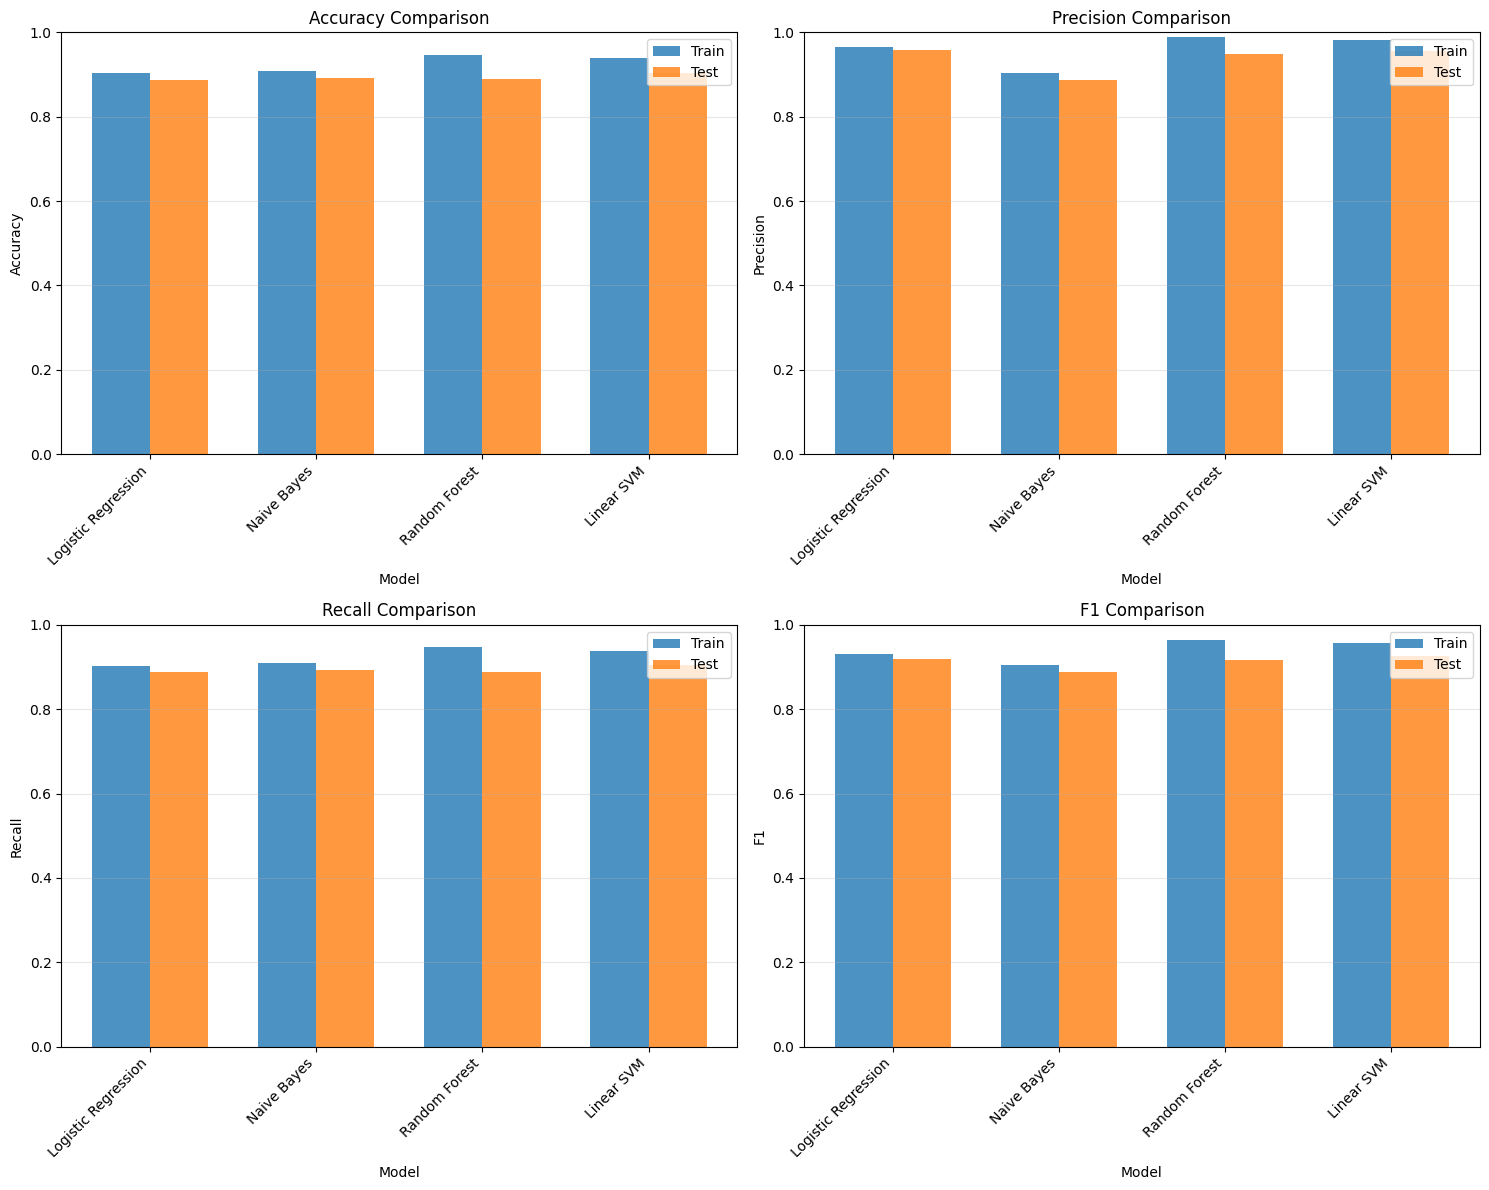


🏆 Best Model: Linear SVM


In [10]:
print("\n" + "="*70)
print("MODEL TRAINING")
print("="*70)

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',  # Handle class imbalance
        random_state=RANDOM_STATE
    ),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    )
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    model.fit(X_train_vectorized, y_train_encoded)
    print("✓ Model trained")
    
    # Predictions
    y_train_pred = model.predict(X_train_vectorized)
    y_test_pred = model.predict(X_test_vectorized)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train_encoded, y_train_pred)
    test_acc = accuracy_score(y_test_encoded, y_test_pred)
    
    train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
        y_train_encoded, y_train_pred, average='weighted', zero_division=0
    )
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
        y_test_encoded, y_test_pred, average='weighted', zero_division=0
    )
    
    # Store results
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train Precision': train_precision,
        'Test Precision': test_precision,
        'Train Recall': train_recall,
        'Test Recall': test_recall,
        'Train F1': train_f1,
        'Test F1': test_f1
    })
    
    print(f"\nResults:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Test F1 Score:  {test_f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    train_col = f'Train {metric}'
    test_col = f'Test {metric}'
    
    x = np.arange(len(results_df))
    width = 0.35
    
    ax.bar(x - width/2, results_df[train_col], width, label='Train', alpha=0.8)
    ax.bar(x + width/2, results_df[test_col], width, label='Test', alpha=0.8)
    
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.loc[results_df['Test F1'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")

# 8. CROSS-VALIDATION


CROSS-VALIDATION

Linear SVM - Cross-Validation Results:
  Fold scores: ['0.9280', '0.9262', '0.9285', '0.9302', '0.9195']
  Mean F1: 0.9265
  Std F1: 0.0037


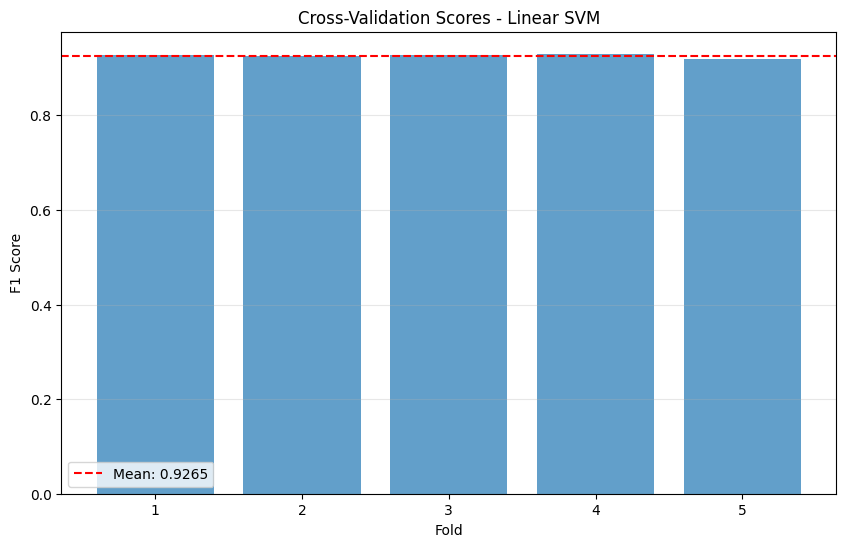

In [11]:
print("\n" + "="*70)
print("CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation on best model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    best_model, X_train_vectorized, y_train_encoded,
    cv=skf, scoring='f1_weighted', n_jobs=-1
)

print(f"\n{best_model_name} - Cross-Validation Results:")
print(f"  Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"  Mean F1: {cv_scores.mean():.4f}")
print(f"  Std F1: {cv_scores.std():.4f}")

# Visualize CV results
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title(f'Cross-Validation Scores - {best_model_name}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


# 9. DETAILED EVALUATION OF BEST MODEL


DETAILED EVALUATION - Linear SVM

Classification Report:
              precision    recall  f1-score   support

     abusive       0.90      0.85      0.87       651
    bullying       0.99      0.94      0.96      2899
     neutral       0.88      0.83      0.85       630
   sarcastic       0.08      0.71      0.15        31

    accuracy                           0.90      4211
   macro avg       0.71      0.83      0.71      4211
weighted avg       0.95      0.90      0.93      4211



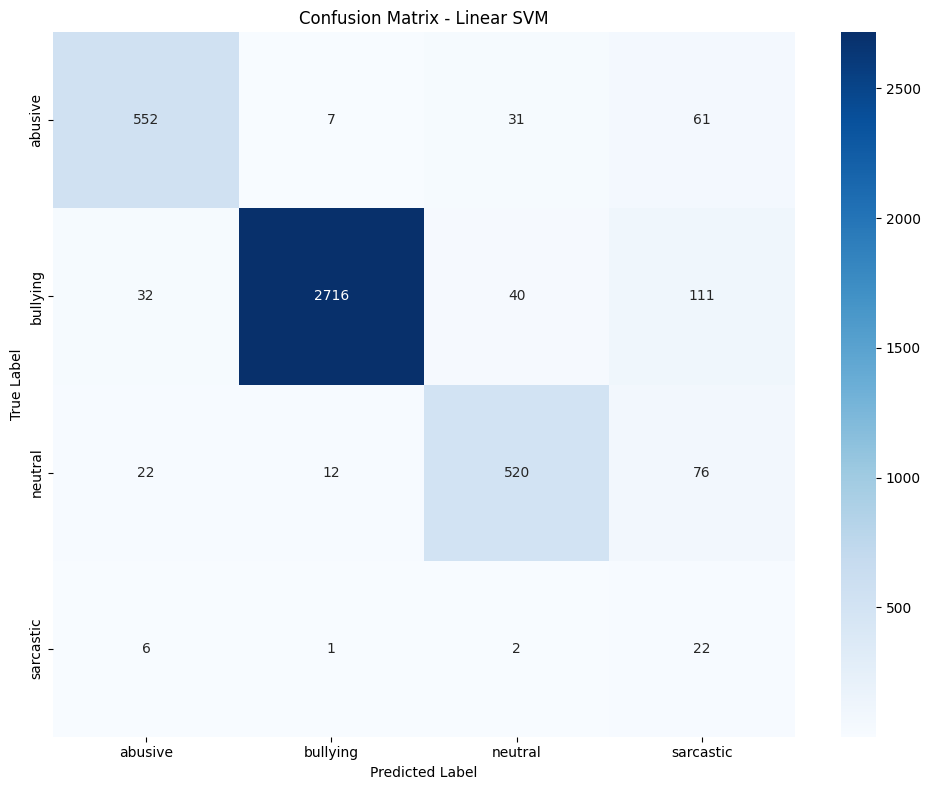

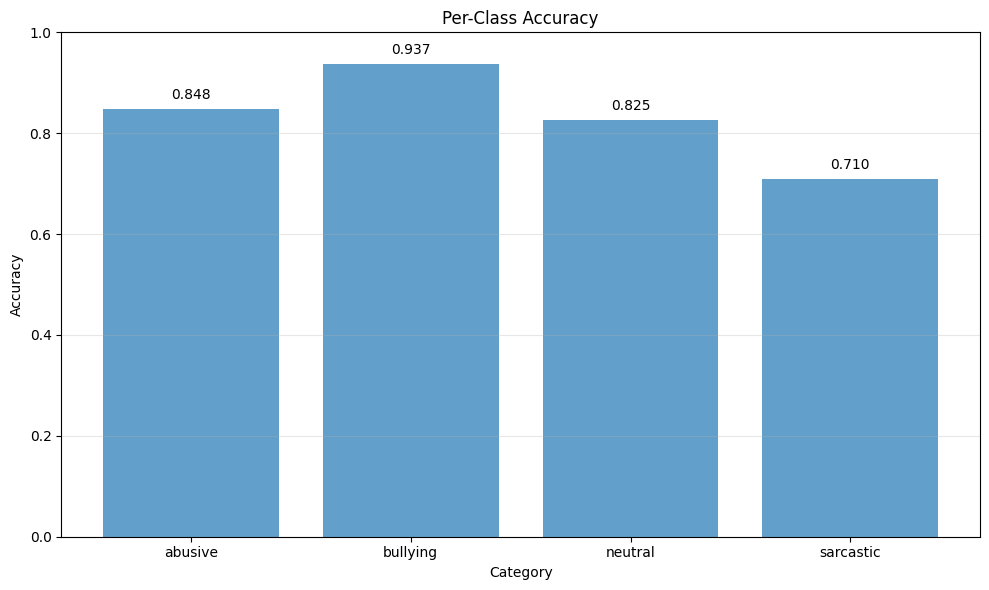

In [12]:
print("\n" + "="*70)
print(f"DETAILED EVALUATION - {best_model_name}")
print("="*70)

# Retrain best model on full training set
best_model.fit(X_train_vectorized, y_train_encoded)
y_test_pred = best_model.predict(X_test_vectorized)

# Classification report
print("\nClassification Report:")
print("="*50)
print(classification_report(y_test_encoded, y_test_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 6))
plt.bar(le.classes_, per_class_accuracy, alpha=0.7)
plt.xlabel('Category')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=0)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_accuracy):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


# 10. FEATURE IMPORTANCE (for Logistic Regression)

In [13]:
if best_model_name == 'Logistic Regression':
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*70)
    
    feature_names = tfidf.get_feature_names_out()
    
    for idx, class_name in enumerate(le.classes_):
        print(f"\n{class_name.upper()}:")
        print("-" * 40)
        
        # Get coefficients for this class
        coef = best_model.coef_[idx]
        
        # Top positive features
        top_positive_idx = coef.argsort()[-10:][::-1]
        print("Top predictive features:")
        for i, feat_idx in enumerate(top_positive_idx, 1):
            print(f"  {i}. {feature_names[feat_idx]}: {coef[feat_idx]:.4f}")


# 11. MODEL PERSISTENCE

In [14]:
print("\n" + "="*70)
print("SAVING MODELS")
print("="*70)

# Save best model
joblib.dump(best_model, f'{best_model_name.replace(" ", "_").lower()}_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print(f"✓ Saved: {best_model_name.replace(' ', '_').lower()}_model.pkl")
print("✓ Saved: tfidf_vectorizer.pkl")
print("✓ Saved: label_encoder.pkl")



SAVING MODELS
✓ Saved: linear_svm_model.pkl
✓ Saved: tfidf_vectorizer.pkl
✓ Saved: label_encoder.pkl


# 12. PREDICTION FUNCTION

In [15]:

def predict_cyberbullying(text, model, vectorizer, label_encoder):
    """
    Predict cyberbullying category for new text
    
    Args:
        text (str): Input text
        model: Trained classifier
        vectorizer: Fitted TF-IDF vectorizer
        label_encoder: Fitted label encoder
    
    Returns:
        tuple: (prediction, confidence)
    """
    # Preprocess
    processed_text = preprocess_text(text)
    
    # Vectorize
    text_vectorized = vectorizer.transform([processed_text])
    
    # Predict
    prediction_encoded = model.predict(text_vectorized)[0]
    prediction = label_encoder.inverse_transform([prediction_encoded])[0]
    
    # Get probability
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(text_vectorized)[0]
        confidence = max(probabilities)
    else:
        confidence = 1.0  # For models without predict_proba
    
    return prediction, confidence

# Test prediction function
print("\n" + "="*70)
print("TESTING PREDICTION FUNCTION")
print("="*70)

test_samples = [
    "I hate you so much!",
    "You are beautiful and amazing!",
    "This is just a normal message.",
]

for sample in test_samples:
    prediction, confidence = predict_cyberbullying(sample, best_model, tfidf, le)
    print(f"\nText: '{sample}'")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2%}")



TESTING PREDICTION FUNCTION

Text: 'I hate you so much!'
Prediction: neutral
Confidence: 100.00%

Text: 'You are beautiful and amazing!'
Prediction: neutral
Confidence: 100.00%

Text: 'This is just a normal message.'
Prediction: neutral
Confidence: 100.00%


# 13. SUMMARY

In [16]:

print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"""
✓ Dataset: {len(df)} samples with {len(le.classes_)} categories
✓ Best Model: {best_model_name}
✓ Test Accuracy: {results_df[results_df['Model'] == best_model_name]['Test Accuracy'].values[0]:.4f}
✓ Test F1 Score: {results_df[results_df['Model'] == best_model_name]['Test F1'].values[0]:.4f}
✓ Cross-Validation F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})

Models saved successfully!
Ready for deployment.
""")

print("="*70)
print("END OF ANALYSIS")
print("="*70)





PROJECT SUMMARY

✓ Dataset: 21054 samples with 4 categories
✓ Best Model: Linear SVM
✓ Test Accuracy: 0.9048
✓ Test F1 Score: 0.9271
✓ Cross-Validation F1: 0.9265 (±0.0037)

Models saved successfully!
Ready for deployment.

END OF ANALYSIS
